# Statistiques de flir

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrivals/EmbeddedComputervision/blob/main/notebooks/flir/flir_stats.ipynb)

Présentation et analyse statistique du jeu, lues du point de vue de Tiny-YOLO et de la
cible embarquée (entrée 416, grilles 13×13 et 26×26, 256 emplacements de `yolo_post`,
INT8). Tâches : [T11.7](../../docs/tasks/M11-jeux-de-donnees.md), [T16.16](../../docs/tasks/M16-presentation-jeux.md), [T16.4](../../docs/tasks/M16-presentation-jeux.md) ; jalon : [M16](../../docs/tasks/M16-presentation-jeux.md) ;
synthèse : [stats-jeux.md](../../docs/tasks/stats-jeux.md). Autres notebooks du jeu :
[tiny-yolov2-voc_infer](tiny-yolov2-voc_infer.ipynb), [tiny-yolov3-coco_infer](tiny-yolov3-coco_infer.ipynb), [tiny-yolov3-flir_infer](tiny-yolov3-flir_infer.ipynb), [tiny-yolov3-flir_train](tiny-yolov3-flir_train.ipynb), [tiny-yolov3-flir_sweep](tiny-yolov3-flir_sweep.ipynb).

Palier : annotations **R** (split entier), pixels **M** (`SAMPLE = 200`
images par partie). Prérequis : données `data/flir/images_thermal_val/coco.json` — tools/get_datasets.sh flir (inscription : source affichée). Ni poids ni GPU.

Question propre : Distribution des niveaux thermiques, et ce qu'en garde l'INT8 de L00. (renvoi : T11.7).

| | |
|---|---|
| source | https://www.flir.com/oem/adas/adas-dataset-form/ |
| version | v2 (2022), images_thermal_train et images_thermal_val |
| licence | licence Teledyne FLIR du jeu ADAS, recherche non commerciale |
| capteur | caméra thermique Boson/Tau2 sur voiture, jour et nuit, 8 bits |
| résolution typique | 640×512 |
| officiel `train` | 10742 images, — objets |
| officiel `val` | 1144 images, — objets |
| chargeur | catégories hors `FLIR_CLASSES` ignorées par `parse_coco` |
| chargeur | images 8 bits du jeu ; analyse 16 bits hors périmètre |

Aucun calcul ici : `tools/data_stats.py` calcule (`stats.json`, `stats.md`, galerie),
`tools/figures/donnees.py` trace ; chaque étape affiche la commande. Sorties dans
`build/notebooks/flir/stats/`, jamais dans `results/`. Notebook généré par `python -m tools.notebooks`
(`make notebooks`) : modifier `tools/notebooks/gabarits.py`, pas ce fichier.

## Paramètres

In [1]:
DATASET   = 'flir'  # clé de DATASETS
SPLITS    = None  # liste de splits ; None : splits train puis test du jeu
SIZE      = None  # S ou 'LxH' ; None : entrée de la cfg du jeu (416 sinon)
RESIZE    = 'letterbox'  # letterbox | stretch (grandeurs vues par le réseau)
SAMPLE    = 200  # images lues pour les pixels, par partie ; 0 : aucune
GALLERY   = 8  # images de la galerie par split
SEED      = 0  # tirage des images (pixels, galerie, nuages)
NET       = 'build/m11/cfg/tiny-yolov3-flir-c1.cfg'  # cfg dont les ancres et grilles servent aux collisions
DEVICE    = 'cpu'  # noyau CPU : rien ne tourne sur GPU
DATA_ROOT = None  # racine du jeu ; None : data/<jeu> (Colab : dossier Drive)
DRIVE_DIR = '/content/drive/MyDrive/EmbeddedCV'  # Colab : archives data/<jeu>.tar ; None : pas de Drive
OUT       = 'build/notebooks/flir/stats'  # sorties du notebook
REPO_URL  = 'https://github.com/lrivals/EmbeddedComputervision.git'  # Colab : dépôt cloné
REV       = 'main'  # Colab : révision

## Environnement

Local : rien n'est installé ni téléchargé, la cellule vérifie les prérequis et
s'arrête avec la commande à lancer. Colab : clone du dépôt, installation, CuPy si
`DEVICE = "gpu"`, poids, puis données par `colab.prepare_data` (archive
`<DRIVE_DIR>/data/<jeu>.tar` ou téléchargement direct ; ExDark et FLIR : archive
seulement, faite sur le PC par `tools/get_datasets.sh pack <jeu>`).

In [2]:
import os
import subprocess
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules


def repo_root():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "tools" / "notebooks" / "commandes.py").exists():
            return d
    return None


ROOT = repo_root()
if COLAB:
    if ROOT is None:
        ROOT = Path("/content/EmbeddedComputervision")
        if not ROOT.exists():
            subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    # Clone d'une session précédente : remis à REV (notebook et code du même commit).
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin", REV], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "-q", "FETCH_HEAD"], check=True)
    for m in [m for m in sys.modules if m.split(".")[0] in ("tools", "yolo")]:
        del sys.modules[m]  # modules importés avant la mise à jour
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    f"{ROOT}/python[data,plots]"], check=True)
    if DEVICE == "gpu":
        # Runtime CPU : pas de pilote, CuPy dirait « cudaErrorInsufficientDriver ».
        try:
            smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        except FileNotFoundError:
            smi = None
        if smi is None or smi.returncode != 0:
            raise RuntimeError("runtime Colab sans GPU : créer un nouveau serveur Colab "
                               "de type GPU (T4, L4 ou A100), ou DEVICE = 'cpu'")
        cuda = smi.stdout.split("CUDA Version:")[-1].split()[0]  # version du pilote
        cupy_pkg = "cupy-cuda13x" if int(cuda.split(".")[0]) >= 13 else "cupy-cuda12x"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", cupy_pkg],
                       check=True)
elif ROOT is None:
    raise RuntimeError("racine du dépôt introuvable : ouvrir le notebook depuis notebooks/")
os.chdir(ROOT)
for p in (ROOT, ROOT / "python"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tools.notebooks import commandes as C
from tools.notebooks import env

TRACE = env.trace(DEVICE)
env.check_device(DEVICE)
env.prepare(DATASET, (), None, DATA_ROOT, COLAB, hint='',
            drive_dir=DRIVE_DIR)
if str(NET).endswith(".cfg") and not env.restore_cfg(NET):
    print(f"cfg {NET} absente (tools/m11.sh {DATASET}-prep) : ancres et grilles de "
          "tiny-yolov3-coco pour les collisions")
    NET = "tiny-yolov3-coco"
Path(OUT).mkdir(parents=True, exist_ok=True)

dépôt /home/leonard/Documents/Perso/EmbeddedComputervision @ 214f269 (modifié) ; Python 3.12.3 ; NumPy 2.4.2 ; backend cpu
données flir : data/flir/images_thermal_val/coco.json ; poids : —


## Calcul (T16.0)

`tools/data_stats.py` lit les annotations de chaque split (en entier), lit les pixels
de `SAMPLE` images par partie (tirées avec `SEED`), dessine la galerie et trace les
figures. Les grandeurs « vues par le réseau » sont calculées après `RESIZE` à `SIZE`.

In [3]:
import json

from IPython.display import Image as Img, Markdown, display

from tools import data_stats as DS
from tools.notebooks.matrice import SPLIT_IMAGES, palier_stats
from yolo.models.tiny_yolo import load_cfg

if SIZE is None:
    _, h, w = load_cfg(NET)["input"]
    SIZE = h if h == w else f"{w}x{h}"
ann, px = palier_stats(DATASET, SAMPLE)
print(f"palier : annotations {ann}, pixels {px} ({SAMPLE} images par partie) ; "
      f"entrée {SIZE} ({RESIZE}) ; cfg {NET}")
C.run(C.cmd_data_stats(DATASET, OUT, SPLITS, SIZE, RESIZE, NET, SAMPLE, GALLERY, SEED,
                       data_root=DATA_ROOT))
STATS = json.loads(Path(OUT, "stats.json").read_text())
FIG = Path(OUT, "figures")


def show(name):
    png = FIG / f"{name}.png"
    if png.exists():
        display(Img(filename=str(png)))


def table(fn):
    text = fn(STATS)
    if text:
        display(Markdown(text))

palier : annotations R, pixels M (200 images par partie) ; entrée 416 (letterbox) ; cfg build/m11/cfg/tiny-yolov3-flir-c1.cfg
$ python tools/data_stats.py --dataset flir --size 416 --resize letterbox --net build/m11/cfg/tiny-yolov3-flir-c1.cfg --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/flir/stats


chargement flir train…


chargement flir val…


analyses train (10742 images)…


analyses val (1144 images)…


...

→ build/notebooks/flir/stats/figures/intensites.png


→ build/notebooks/flir/stats/figures/ancres.png


→ build/notebooks/flir/stats/figures/ancres_k.png


→ build/notebooks/flir/stats/figures/ecart.png


  (38 s)


## Présentation et galerie (T16.4)

Classes du jeu et leur correspondance VOC et COCO (`MAPPINGS`), puis `GALLERY` images
par split, une image par classe ; vérités terrain dessinées par `tools/detect.py:draw`.
À `SEED` fixé, la galerie ne change pas.

| classe | VOC | COCO |
|---|---|---|
| person | person | person |
| bike | bicycle | bicycle |
| car | car | car |
| motor | motorbike | motorbike |
| bus | bus | bus |
| train | train | train |
| truck | — | truck |
| light | — | traffic light |
| hydrant | — | fire hydrant |
| sign | — | — |
| dog | dog | dog |
| skateboard | — | skateboard |
| stroller | — | — |
| scooter | — | — |
| other vehicle | — | — |

galerie : train


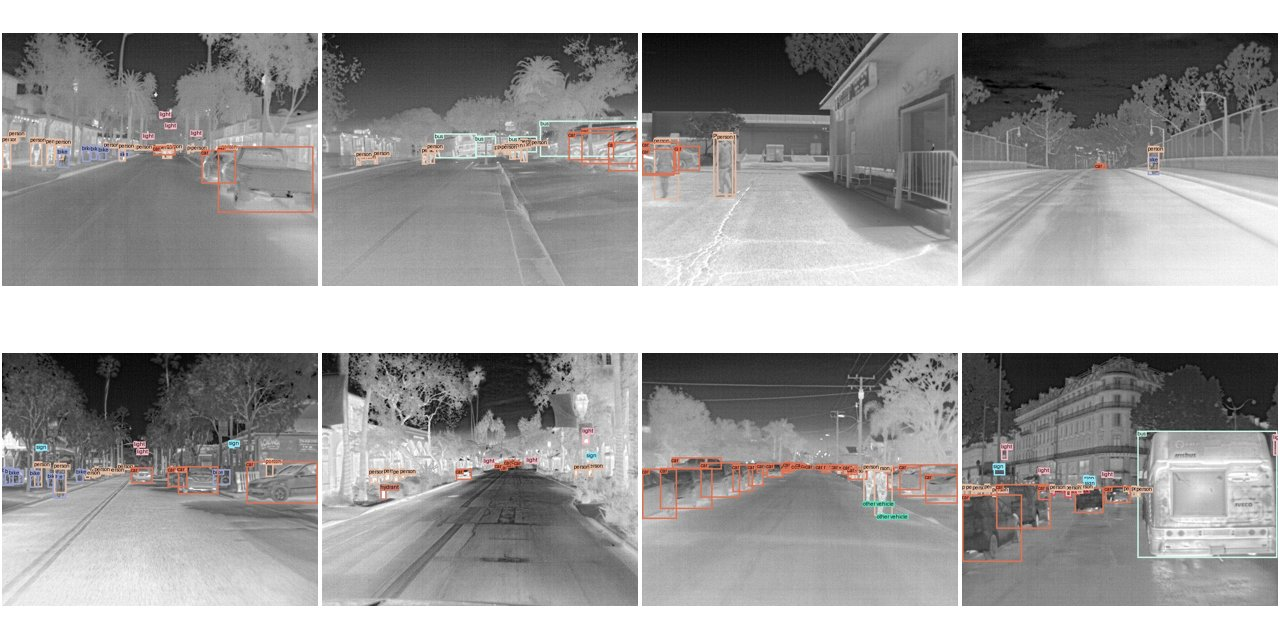

galerie : val


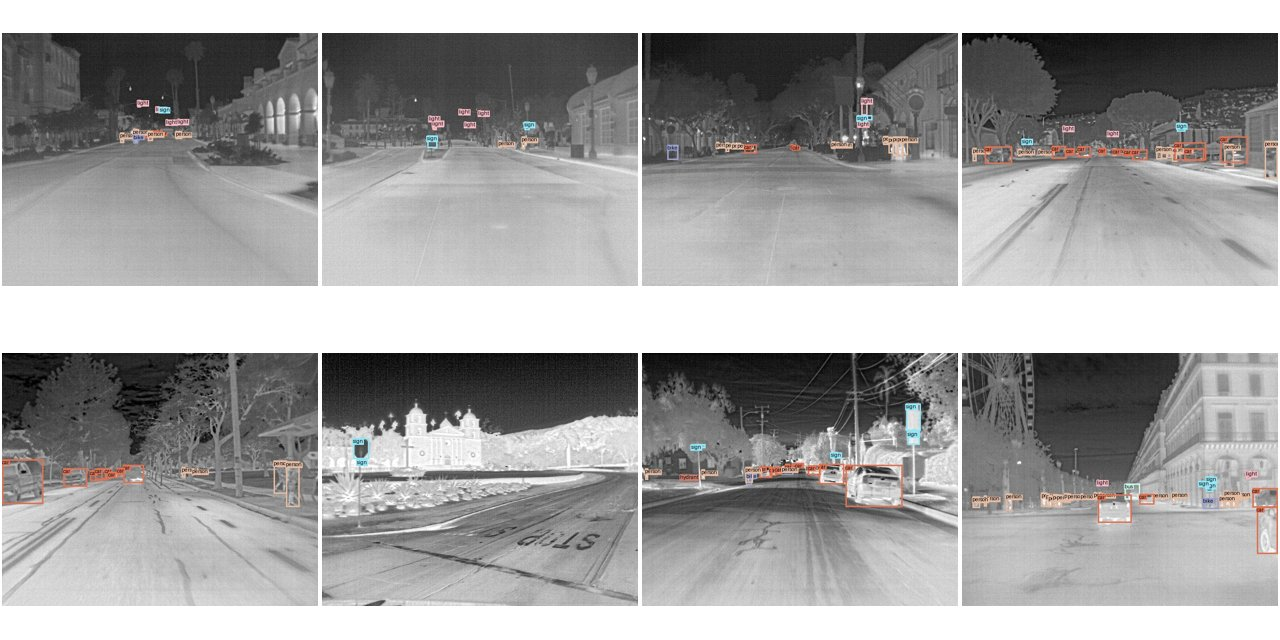

galerie : classes


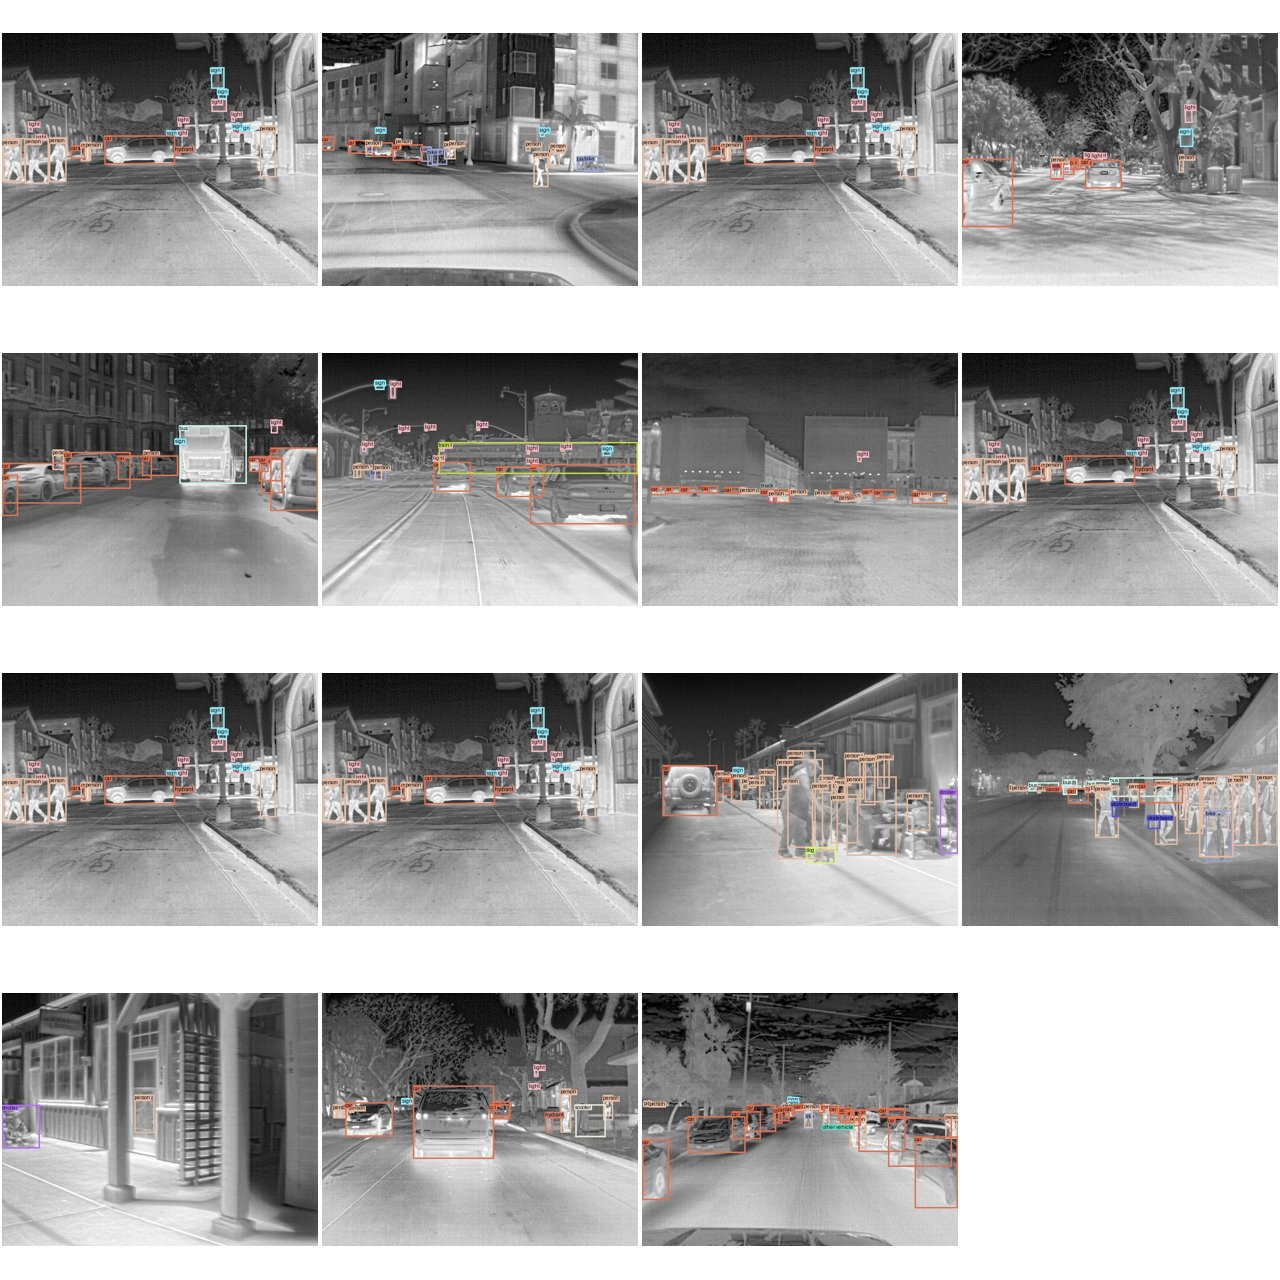

In [4]:
from yolo.data import datasets as D

rows = ["| classe | VOC | COCO |", "|---|---|---|"]
for c in D.DATASETS[DATASET].classes:
    m = [c if DATASET == f else D.MAPPINGS.get((DATASET, f), {}).get(c, "—")
         for f in ("voc", "coco")]
    rows.append(f"| {c} | {m[0]} | {m[1]} |")
display(Markdown("\n".join(rows)))
for g, sheet in STATS.get("galerie", {}).get("planches", {}).items():
    if g != "suspectes":
        print(f"galerie : {g}")
        display(Img(filename=str(Path(OUT, sheet))))

## Comptes et classes (T16.5)

Comptes par split (annotations, split entier), face aux effectifs officiels de la
fiche ; objets par classe et co-occurrence.

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| train | 10 742 | 175 032 | 0 | 264 | 15 / 93 | 85,6 % | 13x13 77,6 % · 26x26 50,6 % | 18,06 % | 0 / 0 |
| val | 1 144 | 16 696 | 0 | 16 | 14 / 63 | 86,3 % | 13x13 79,4 % · 26x26 51,2 % | 13,87 % | 0 / 0 |
| ensemble | 11 886 | 191 728 | 0 | 280 | 15 / 93 | 85,6 % | 13x13 77,8 % · 26x26 50,7 % | 17,70 % | 0 / 0 |

train : 10742 images, 175032 objets ; officiel 10742 / — : ok
val : 1144 images, 16696 objets ; officiel 1144 / — : ok


| classe | train : objets (images) | val : objets (images) | côté médian (px, letterbox) | petits |
|---|---|---|---|---|
| person | 50 478 (8 205) | 4 470 (819) | 11 | 91 % |
| bike | 7 237 (3 096) | 170 (135) | 16 | 84 % |
| car | 73 623 (9 824) | 7 133 (1 047) | 15 | 77 % |
| motor | 1 116 (744) | 55 (47) | 24 | 64 % |
| bus | 2 245 (1 296) | 179 (126) | 26 | 63 % |
| train | 5 (5) | 0 (0) | 104 | 0 % |
| truck | 829 (708) | 46 (42) | 26 | 61 % |
| light | 16 198 (3 695) | 2 005 (439) | 7 | 99 % |
| hydrant | 1 095 (1 075) | 94 (93) | 7 | 99 % |
| sign | 20 770 (6 802) | 2 472 (848) | 8 | 98 % |
| dog | 4 (4) | 0 (0) | 29 | 75 % |
| skateboard | 29 (19) | 3 (3) | 5 | 100 % |
| stroller | 15 (15) | 6 (6) | 36 | 43 % |
| scooter | 15 (15) | 0 (0) | 25 | 67 % |
| other vehicle | 1 373 (953) | 63 (53) | 21 | 64 % |

Rapport classe la plus / la moins fréquente : 20 189.

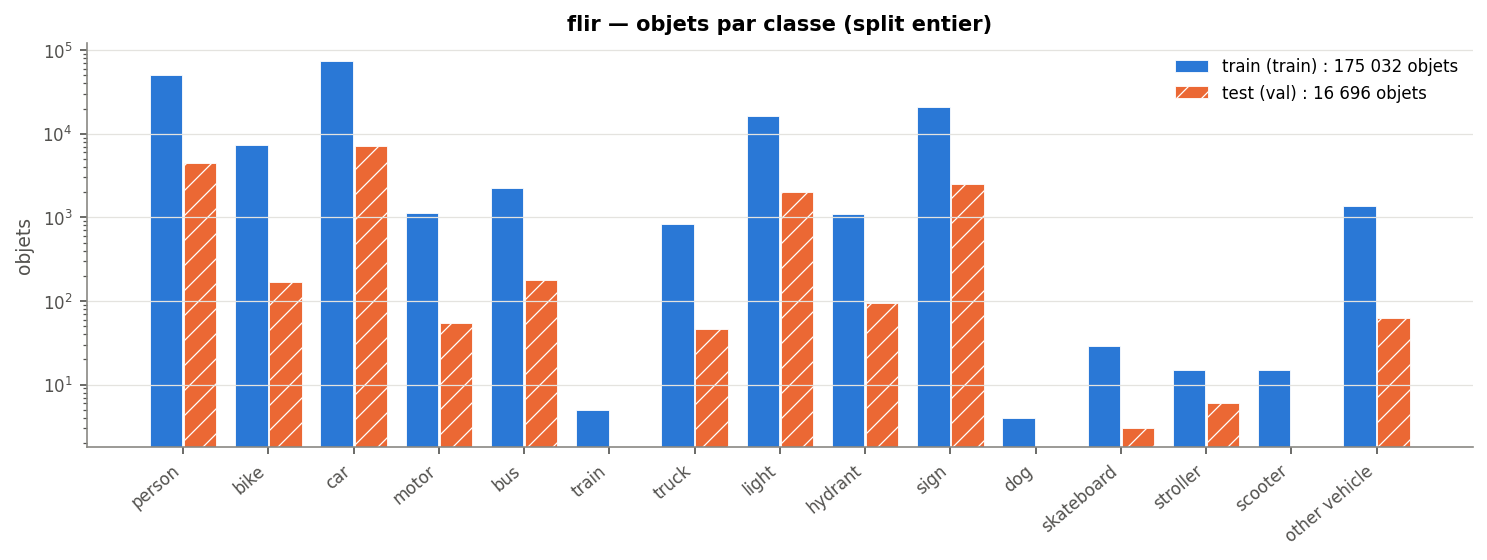

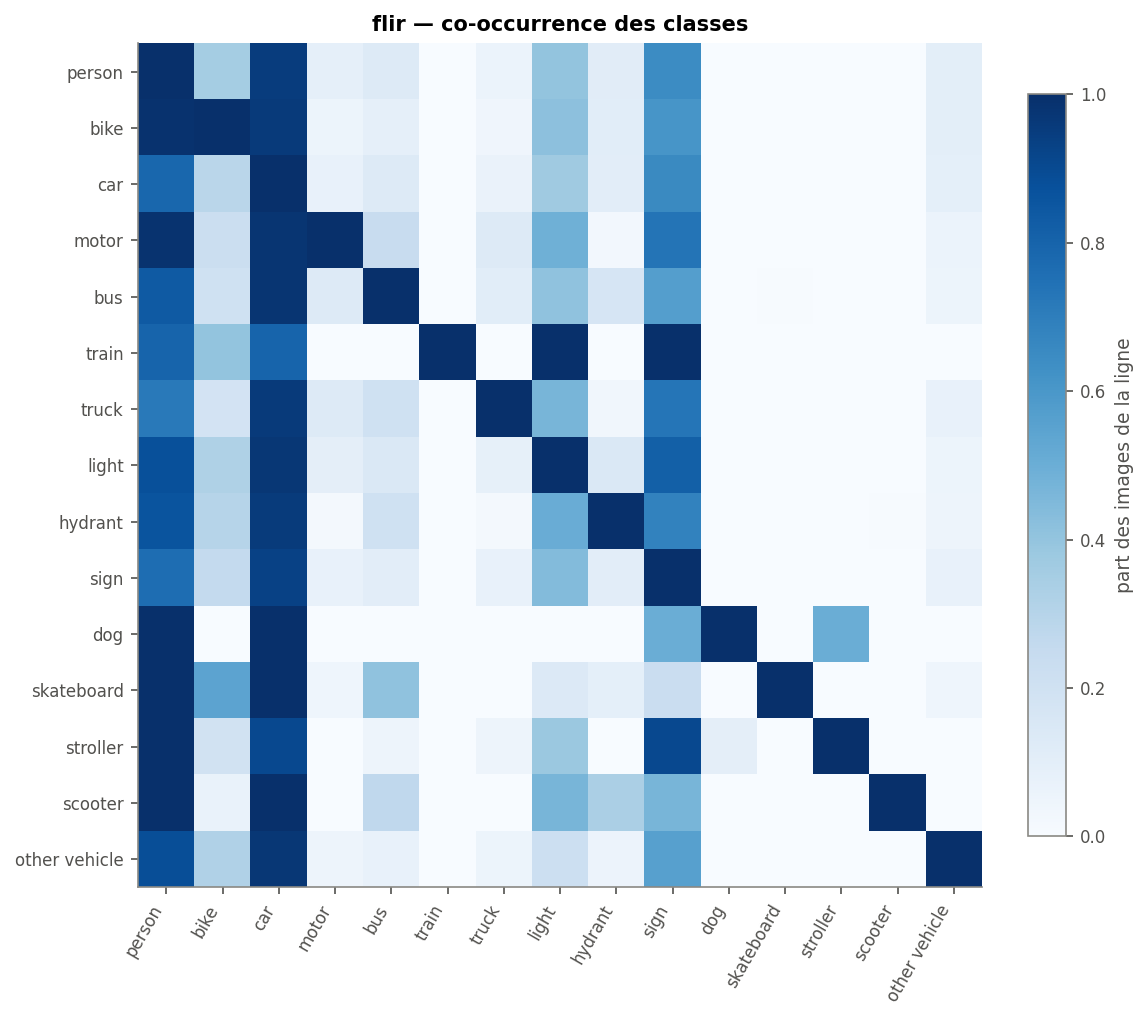

In [5]:
table(DS.md_synthese)
chk = DS.check_official(STATS)
for sp, i, o, (a, b), ok in chk:
    print(f"{sp} : {i} images, {o} objets ; officiel {a or '—'} / {b or '—'} : "
          f"{'ok' if ok else 'écart (voir les notes de la fiche)'}")
table(DS.md_classes)
show("classes")
show("cooccurrence")

## Géométrie des boîtes (T16.6)

Tailles en pixels d'origine et d'entrée (letterbox et stretch à `SIZE`), catégories
COCO avant et après redimensionnement, part des objets plus petits qu'une cellule de
chaque tête, centres des boîtes.

| repère | petits | moyens | grands | côté médian (px) | plus petits qu'une cellule | hauteur < 8 px |
|---|---|---|---|---|---|---|
| image d'origine | 73,7 % | 22,0 % | 4,3 % | 18 | — | — |
| letterbox 416×416 | 85,6 % | 13,0 % | 1,3 % | 11 | 13x13 77,8 % · 26x26 50,7 % | 26,9 % |
| stretch 416×416 | 83,1 % | 15,1 % | 1,9 % | 13 | 13x13 73,0 % · 26x26 42,7 % | 16,6 % |

191 728 objets non-difficult ; pas des têtes : 13x13 → 32 px, 26x26 → 16 px.

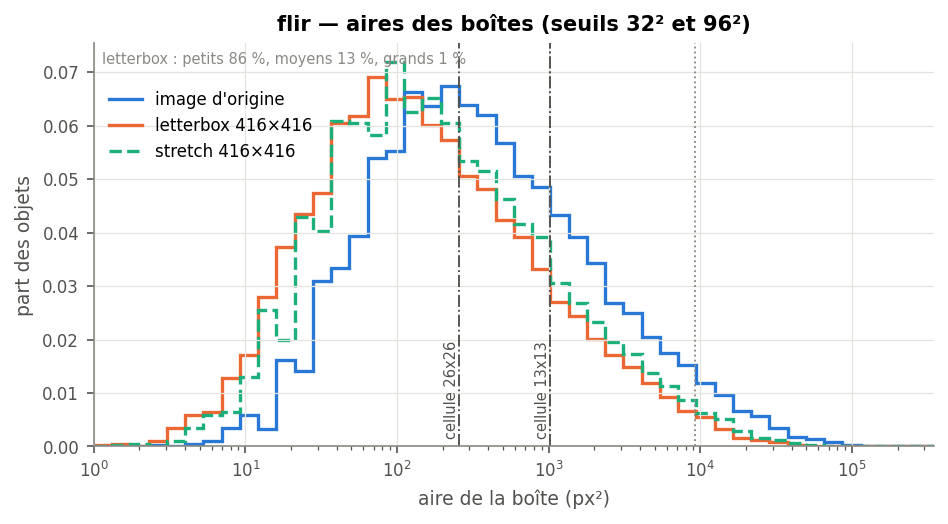

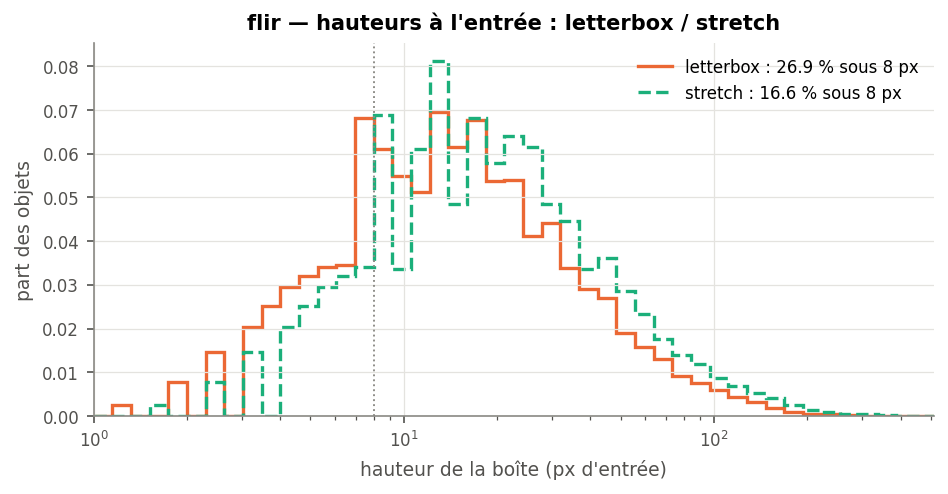

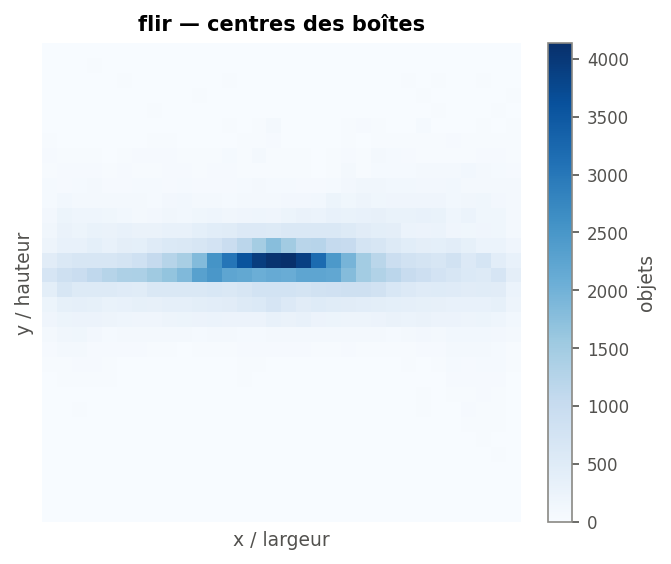

In [6]:
table(DS.md_geometrie)
show("tailles")
show("letterbox_stretch")
show("centres")

## Densité et collisions (T16.7)

Objets par image face aux 256 emplacements de `yolo_post` ; cibles perdues quand deux
objets tombent sur la même cellule et la même ancre (`build_targets`, ancres de `NET`).

| partie | objets/image moy. | méd. | max | > 256 / > 1 024 | cibles perdues | par tête (perdues / objets) | images touchées |
|---|---|---|---|---|---|---|---|
| train | 16,3 | 15 | 93 | 0 / 0 | 31 614 / 175 032 (18,06 %) | 13x13 : 2 292 / 37 165 · 26x26 : 29 322 / 137 867 | 7 672 |
| val | 14,6 | 14 | 63 | 0 / 0 | 2 315 / 16 696 (13,87 %) | 13x13 : 126 / 3 482 · 26x26 : 2 189 / 13 214 | 733 |
| ensemble | 16,1 | 15 | 93 | 0 / 0 | 33 929 / 191 728 (17,70 %) | 13x13 : 2 418 / 40 647 · 26x26 : 31 511 / 151 081 | 8 405 |

Ancres de `build/m11/cfg/tiny-yolov3-flir-c1.cfg` ; objets non-difficult, comme à l'entraînement.

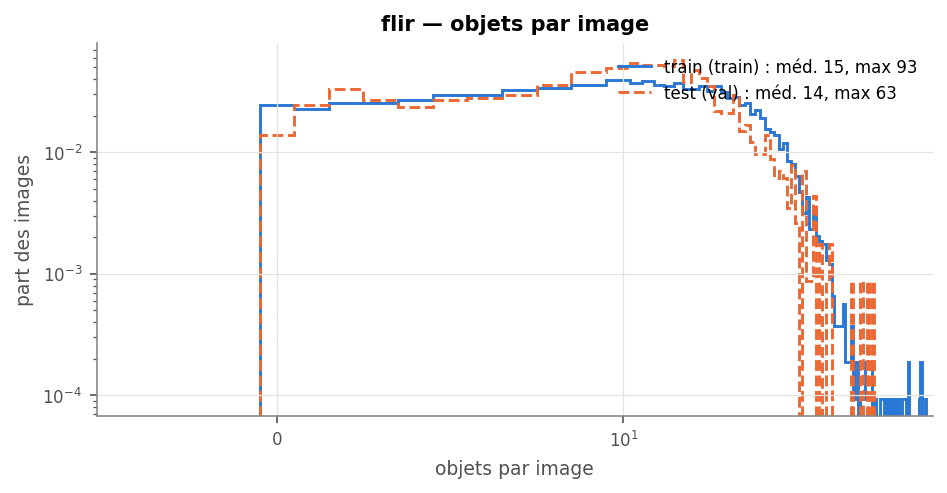

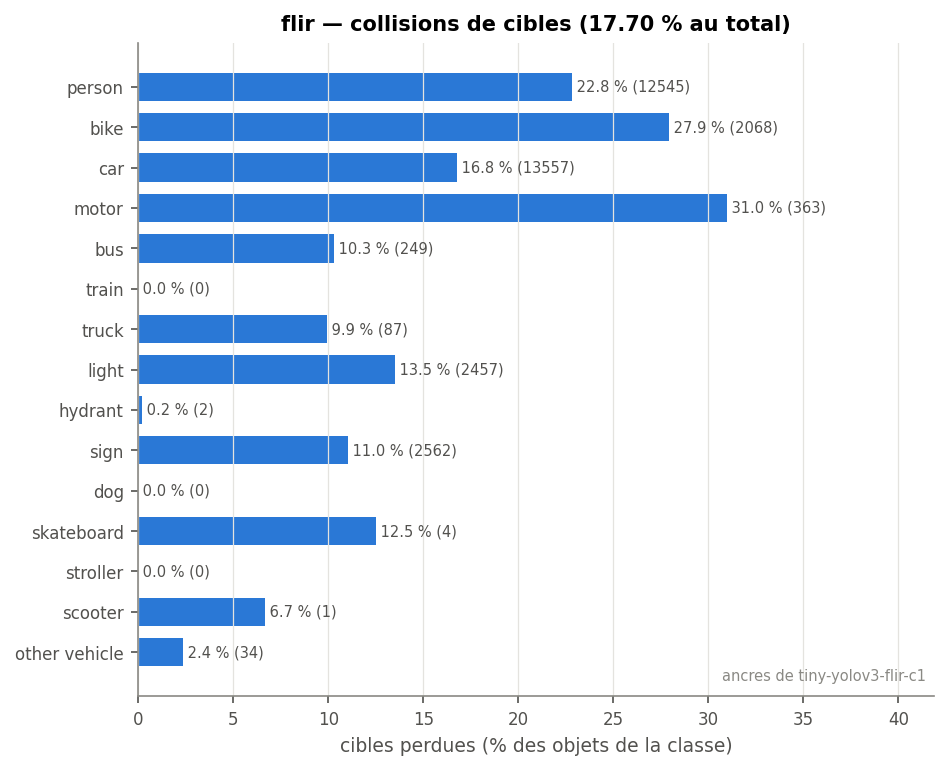

In [7]:
table(DS.md_densite)
show("densite")
show("collisions")

## Images (T16.8)

Résolutions sur le split entier (annotations) ; canaux, intensités et luminance sur
`SAMPLE` images par partie, face à VOC2007 test (échelles INT8 de M4).

| partie | résolutions (3 premières) | distinctes | pixels sur | canaux | moyenne par canal | écart type par canal | luminance moy. | niveaux 8 bits → INT8 |
|---|---|---|---|---|---|---|---|---|
| train | 640×512 (10 742) | 1 | 200 images | 1 | 132,5 | 58,2 | 132,5 | 256 → 128 |
| val | 640×512 (1 144) | 1 | 200 images | 1 | 130,3 | 62,0 | 130,3 | 256 → 128 |
| ensemble | 640×512 (11 886) | 1 | 200 images | 1 | 132,6 | 59,7 | 132,6 | 256 → 128 |

Référence VOC2007 test (200 images, graine 0) : luminance moyenne 107,7, moyenne par canal 112,1 / 107,1 / 98,5.

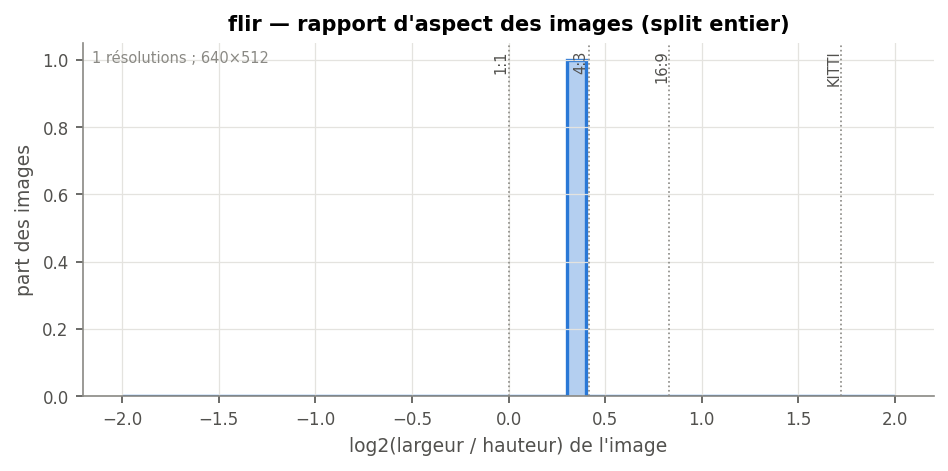

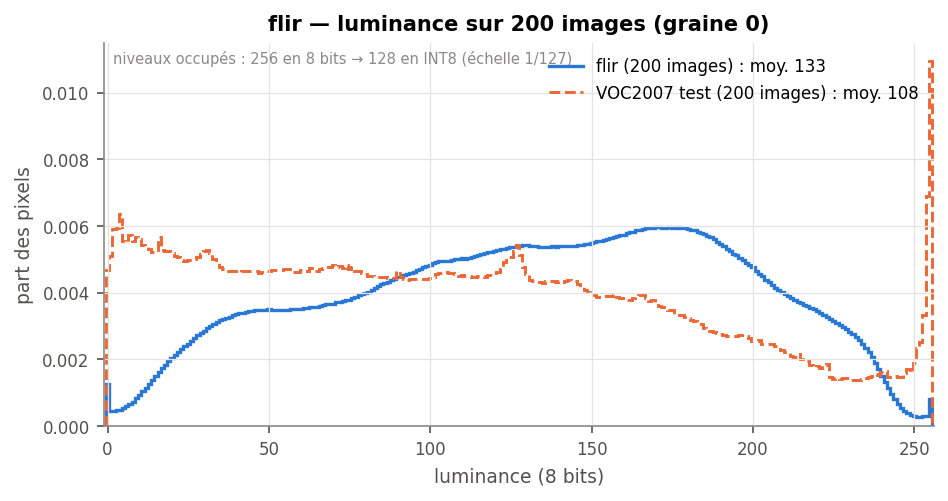

In [8]:
table(DS.md_images)
show("resolutions")
show("intensites")

## Ancres (T16.9)

Boîtes du groupe train en pixels d'entrée letterbox, ancres de la cfg, de VOC, de
COCO et du k-means (`tools/kmeans_anchors.py`, mêmes `--size` et `--seed`).

| ancres | w,h (px à 416×416) | IoU moyenne |
|---|---|---|
| VOC (tiny-yolov2-voc) | `35,38  109,141  212,364  301,164  532,337` | 0,1957 |
| VOC (tiny-yolov3-voc) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,4562 |
| COCO (tiny-yolov3-coco) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,4562 |
| cfg du jeu (tiny-yolov3-flir-c1) | `5,8  12,17  18,44  34,24  61,57  114,117` | 0,5636 |
| k-means k = 5 (graine 0) | `6,8  15,21  36,38  73,60  115,125` | 0,5286 |
| k-means k = 6 (graine 0) | `5,8  12,17  18,44  34,24  61,57  114,117` | 0,5638 |

175 032 boîtes non-difficult du groupe train, letterbox 416×416.

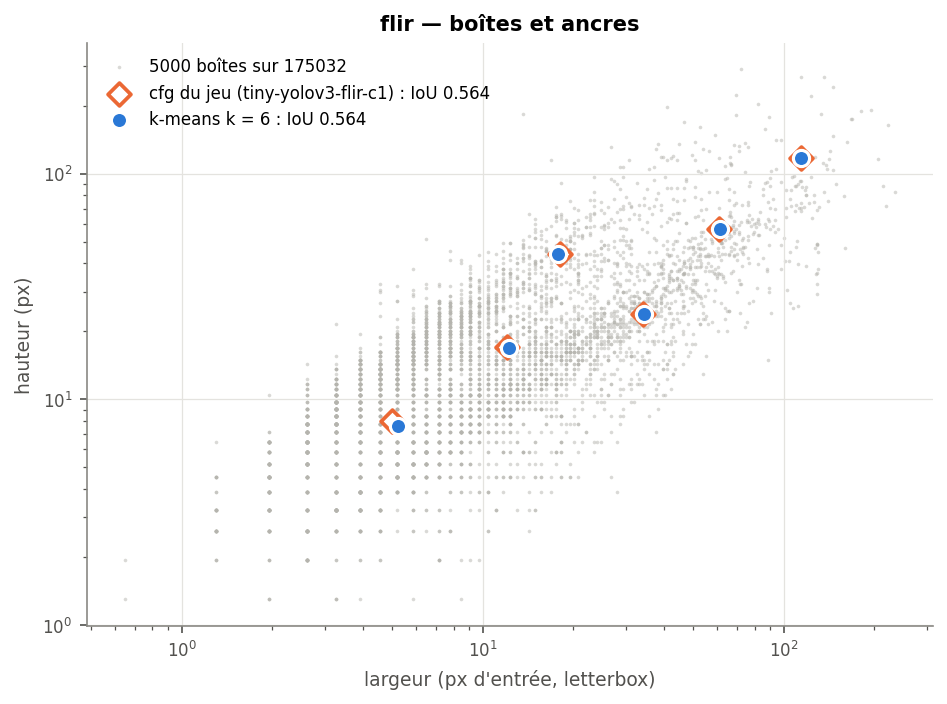

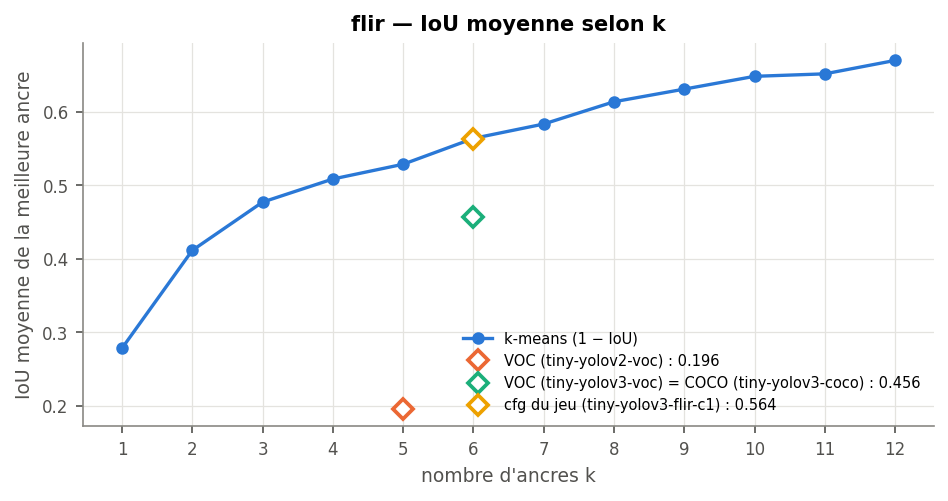

In [9]:
table(DS.md_ancres)
show("ancres")
show("ancres_k")

## Qualité des annotations (T16.10)

Boîtes retirées ou rognées par le chargeur, dégénérées, doublons, régions retirées ;
l'analyse signale, elle ne corrige pas (une correction passe par M11).

| partie | retirées (make_sample) | rognées | côté < 2 px (orig. / entrée) | doublons (IoU > 0,95) | régions retirées par le chargeur |
|---|---|---|---|---|---|
| train | — | 0 | 75 / 6 130 | 3 | — |
| val | — | 0 | 6 / 428 | 11 | — |
| ensemble | — | 0 | 81 / 6 558 | 14 | — |

5808 : score 12 (retirées 0, rognées 0, dégénérées 0, doublons 6)
5825 : score 10 (retirées 0, rognées 0, dégénérées 0, doublons 5)
2648 : score 3 (retirées 0, rognées 0, dégénérées 3, doublons 0)
3022 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)
3522 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)
3526 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)
423 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)
5104 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)
5105 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)
5469 : score 2 (retirées 0, rognées 0, dégénérées 2, doublons 0)


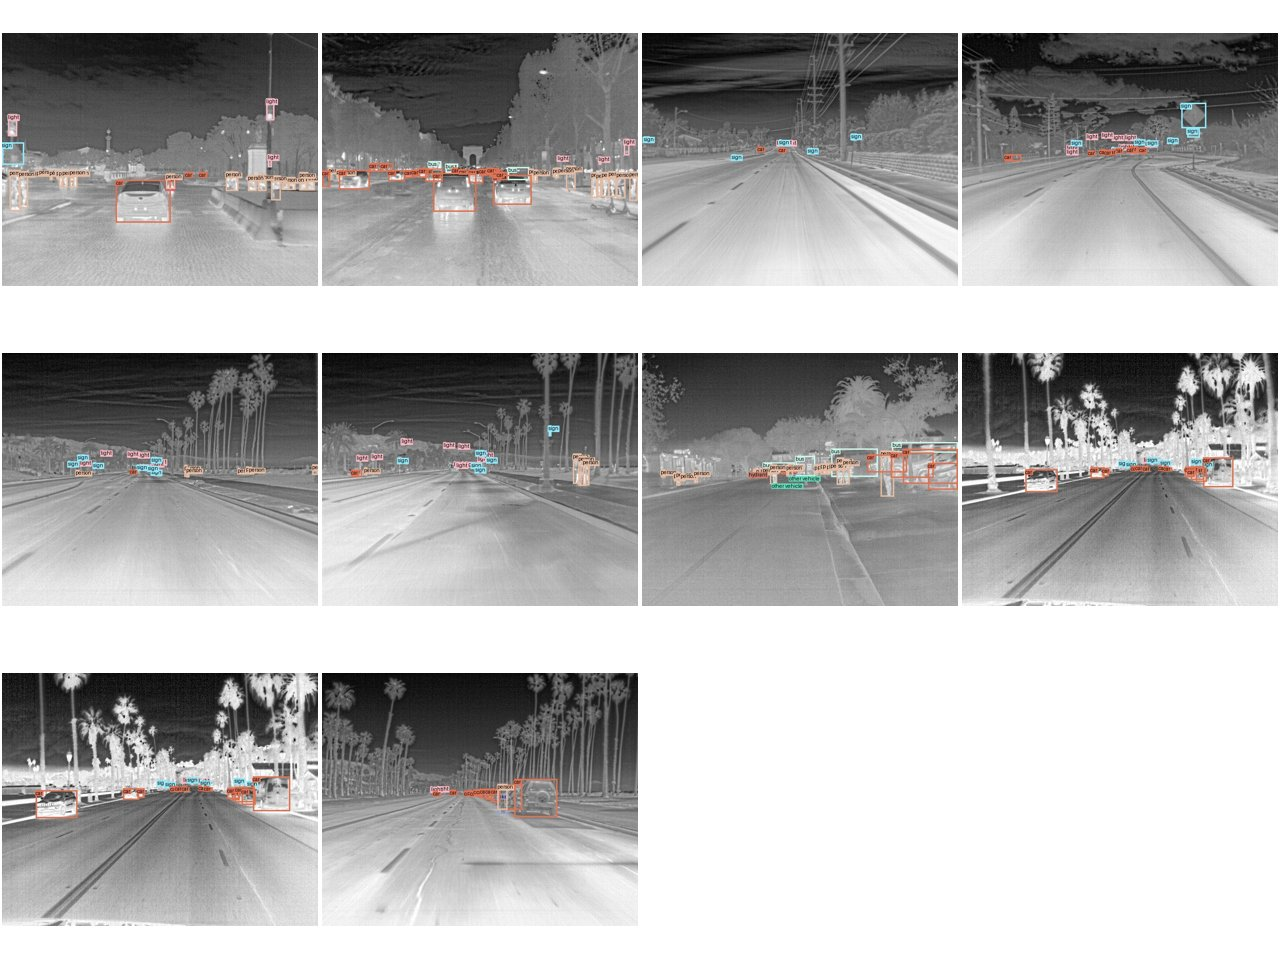

In [10]:
table(DS.md_qualite)
sus = DS.whole(STATS).get("qualite", {}).get("suspects", [])
for d in sus:
    print(f"{d['id']} : score {d['score']} (retirées {d['retirées']}, rognées "
          f"{d['rognées']}, dégénérées {d['dégénérées']}, doublons {d['doublons']})")
sheet = STATS.get("galerie", {}).get("planches", {}).get("suspectes")
if sheet:
    display(Img(filename=str(Path(OUT, sheet))))

## Écart entre splits et couverture hors domaine (T16.11)

Distance en variation totale entre train et test, par grandeur ; part des objets qui
ont une classe VOC ou COCO (ce qu'évaluent les notebooks hors domaine de T14.5).

| grandeur (train ↔ test) | variation totale |
|---|---|
| classes | 0,064 |
| area_in | 0,033 |
| w_in | 0,027 |
| h_in | 0,042 |
| aspect | 0,033 |
| per_image | 0,153 |

| split | classes du modèle | objets couverts | part | évalués (non-difficult) |
|---|---|---|---|---|
| train | VOC | 134 708 | 77,0 % | 134 708 |
| train | COCO | 152 859 | 87,3 % | 152 859 |
| val | VOC | 12 007 | 71,9 % | 12 007 |
| val | COCO | 14 155 | 84,8 % | 14 155 |

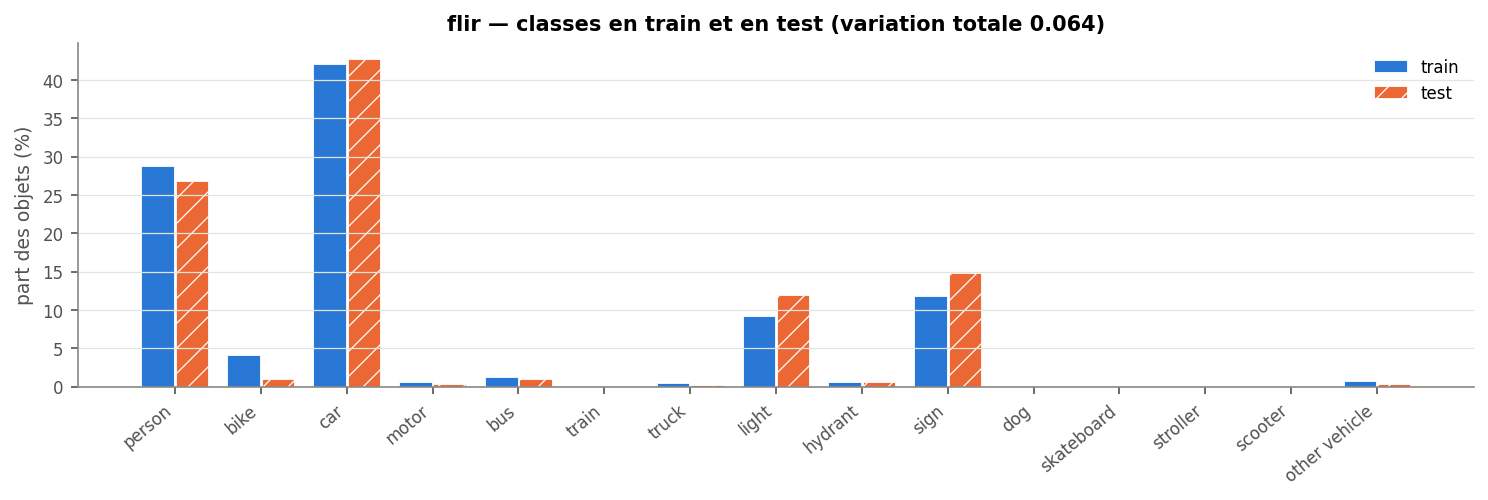

In [11]:
table(DS.md_ecart)
show("ecart")

## Question propre au jeu

Distribution des niveaux thermiques, et ce qu'en garde l'INT8 de L00. (renvoi : T11.7)

In [12]:
px = DS.whole(STATS).get("images", {}).get("pixels")
if px:
    lv = px["levels"]
    print(f"{px['images']} images, {px['channels']} canal(aux) ; niveaux 8 bits occupés "
          f"{lv['8bit']} (99 % des pixels sur {lv['8bit_99']}) → {lv['int8']} niveaux "
          f"INT8 à l'échelle d'entrée {lv['input_scale']:.5f} (1/127, yolo.quant)")
else:
    print("SAMPLE = 0 : pas de lecture de pixels")

200 images, 1 canal(aux) ; niveaux 8 bits occupés 256 (99 % des pixels sur 236) → 128 niveaux INT8 à l'échelle d'entrée 0.00787 (1/127, yolo.quant)


## Résumé

In [13]:
table(DS.md_synthese)
print(f"sorties : {OUT}/ (stats.json, stats.md, figures/, galerie/) ; "
      f"révision {TRACE['rev']}")
print("commandes équivalentes :")
for c in C.HISTORY:
    print("  " + c)

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| train | 10 742 | 175 032 | 0 | 264 | 15 / 93 | 85,6 % | 13x13 77,6 % · 26x26 50,6 % | 18,06 % | 0 / 0 |
| val | 1 144 | 16 696 | 0 | 16 | 14 / 63 | 86,3 % | 13x13 79,4 % · 26x26 51,2 % | 13,87 % | 0 / 0 |
| ensemble | 11 886 | 191 728 | 0 | 280 | 15 / 93 | 85,6 % | 13x13 77,8 % · 26x26 50,7 % | 17,70 % | 0 / 0 |

sorties : build/notebooks/flir/stats/ (stats.json, stats.md, figures/, galerie/) ; révision 214f269
commandes équivalentes :
  python tools/data_stats.py --dataset flir --size 416 --resize letterbox --net build/m11/cfg/tiny-yolov3-flir-c1.cfg --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/flir/stats
